<a href="https://colab.research.google.com/github/kuroshkarimi/Machine-Learning-and-Data-Analysis/blob/main/Deep_Learning/MusicReleaseYear_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task Statement: Music Release Year Prediction Using Regression Models

## Project Overview

You are provided with the **Year Prediction MSD dataset**, a real-world regression dataset derived from the Million Song Dataset. The objective of this project is to predict the **release year of a song** using numerical audio features extracted from music tracks.

Each sample represents one song. The first column contains the target variable, which is the song’s release year. The remaining columns contain numerical audio descriptors that summarize characteristics of the song.

This project is designed to test different regression methods, including classical machine learning models and deep learning models such as a Multilayer Perceptron.

## Objective

The main goal is to build regression models that can predict the release year of a song based on its audio features.

The target variable is:

[
Year
]

The input features are:

[
X_1, X_2, X_3, ..., X_{90}
]

where each feature represents an audio-related numerical descriptor.

The prediction task can be written as:

[
\hat{y} = f(X_1, X_2, ..., X_{90})
]

where:

[
\hat{y}
]

is the predicted release year of the song.

## Dataset Description

The dataset contains a large number of observations and 90 numerical input features. The first column is the target variable, representing the release year. The remaining columns are continuous numerical features extracted from audio data.

This dataset is suitable for testing regression algorithms because it is larger and more complex than many beginner-level regression datasets. The relationship between audio features and release year is expected to be nonlinear and noisy, making it a useful case for evaluating both traditional regression models and neural networks.

## Tasks

### 1. Load and Explore the Dataset

Load the dataset into Python and inspect its structure. Check the number of rows and columns, the range of release years, and the basic statistical properties of the input features.

You should examine:

* Dataset shape
* Target variable distribution
* Feature statistics
* Missing values, if any
* Possible outliers
* Correlations between features and target

### 2. Define Features and Target

Separate the dataset into input features and target variable.

The target variable is the release year:

[
y = Year
]

The input matrix contains the 90 audio features:

[
X = [X_1, X_2, ..., X_{90}]
]

### 3. Train-Test Split

Use the recommended train-test split for this dataset, where the first part of the dataset is used for training and the remaining part is used for testing.

The purpose of this split is to evaluate the model on unseen songs and estimate how well the model generalizes.

### 4. Preprocess the Data

Apply appropriate preprocessing steps before training the models.

At minimum, you should:

* Standardize the input features
* Avoid data leakage by fitting the scaler only on the training data
* Transform the test data using the scaler fitted on the training data

For neural networks, scaling is especially important because unscaled features can make optimization unstable or slow.

### 5. Build Baseline Regression Models

Before applying deep learning, build one or more baseline regression models.

Possible baseline models include:

* Linear Regression
* Ridge Regression
* Lasso Regression
* Random Forest Regressor
* Gradient Boosting Regressor

The baseline models are important because they show whether the MLP provides a real improvement or not.

### 6. Build an MLP Regression Model

Design and train a Multilayer Perceptron for regression.

The MLP should include:

* An input layer matching the number of features
* Several hidden dense layers
* Nonlinear activation functions such as ReLU
* Optional regularization methods such as dropout or batch normalization
* A final output layer with one neuron and no activation function

The final layer should not use softmax or sigmoid because this is a regression problem, not a classification problem.

### 7. Train the Model

Train the MLP using an appropriate optimizer and loss function.

Recommended choices:

* Optimizer: Adam
* Loss function: Mean Squared Error
* Metric: Mean Absolute Error

Use a validation set during training to monitor overfitting. Early stopping can be used to stop training when validation loss no longer improves.

### 8. Evaluate Model Performance

Evaluate all models on the test set using regression metrics.

Recommended metrics:

* Mean Absolute Error
* Root Mean Squared Error
* (R^2) score

Mean Absolute Error is especially interpretable in this project because it tells us the average prediction error in years.

For example, if:

[
MAE = 7
]

then the model is wrong by about seven years on average.

### 9. Compare Models

Compare the performance of the MLP with the baseline regression models.

The comparison should answer the following questions:

* Does the MLP outperform linear regression?
* Does the MLP outperform regularized linear models such as Ridge?
* Is the improvement large enough to justify using a neural network?
* Is the MLP overfitting or generalizing well?
* Which model gives the best balance between accuracy and simplicity?

### 10. Visualize the Results

Create visualizations to better understand model performance.

Useful plots include:

* Training loss vs validation loss
* True release year vs predicted release year
* Residual plot
* Distribution of prediction errors

These plots help identify whether the model is biased, overfitting, underfitting, or making large errors for specific time periods.

## Expected Deliverables

The final project should include:

1. A clear explanation of the dataset and prediction task
2. Exploratory data analysis
3. Data preprocessing steps
4. Baseline regression models
5. MLP regression model
6. Model evaluation using MAE, RMSE, and (R^2)
7. Comparison between models
8. Visualizations of model performance
9. A final discussion of the results

## Final Discussion

In the final discussion, interpret the results critically. A neural network is not automatically better simply because it is more complex. If the MLP performs only slightly better than a simpler model, the simpler model may be preferable.

You should discuss:

* Whether the MLP captured nonlinear relationships
* Whether the model overfitted the training data
* Whether the prediction error is acceptable
* Why predicting the exact release year from audio features is a difficult task
* What could be improved in future work

## Possible Extensions

To improve the project, you may also try:

* Hyperparameter tuning
* Different MLP architectures
* Dropout and batch normalization
* Learning rate adjustment
* Feature selection
* PCA before regression
* Comparing with tree-based models
* Using the full dataset instead of a subset

## Summary

This project investigates whether audio features can be used to predict the release year of songs. The dataset is large, numerical, and suitable for regression. Because the relationship between audio characteristics and release year is likely nonlinear, the project provides a good opportunity to compare traditional regression models with a deep learning model such as an MLP.


In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import RidgeCV

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [91]:
url = "https://archive.ics.uci.edu/static/public/203/yearpredictionmsd.zip"
df = pd.read_csv(url, compression = 'zip', header = None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


In [92]:
# Evaluation of the overall characteristics of the data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515345 entries, 0 to 515344
Data columns (total 91 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       515345 non-null  int64  
 1   1       515345 non-null  float64
 2   2       515345 non-null  float64
 3   3       515345 non-null  float64
 4   4       515345 non-null  float64
 5   5       515345 non-null  float64
 6   6       515345 non-null  float64
 7   7       515345 non-null  float64
 8   8       515345 non-null  float64
 9   9       515345 non-null  float64
 10  10      515345 non-null  float64
 11  11      515345 non-null  float64
 12  12      515345 non-null  float64
 13  13      515345 non-null  float64
 14  14      515345 non-null  float64
 15  15      515345 non-null  float64
 16  16      515345 non-null  float64
 17  17      515345 non-null  float64
 18  18      515345 non-null  float64
 19  19      515345 non-null  float64
 20  20      515345 non-null  float64
 21  21      51

In [93]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
count,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,...,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000
mean,1998.397082,43.387126,1.289554,8.658347,1.164124,-6.553601,-9.521975,-2.391089,-1.793236,3.727876,...,15.755406,-73.461500,41.542422,37.934119,0.315751,17.669213,-26.315336,4.458641,20.035136,1.329105
std,10.931046,6.067558,51.580351,35.268585,16.322790,22.860785,12.857751,14.571873,7.963827,10.582861,...,32.099635,175.618889,122.228799,95.050631,16.161764,114.427905,173.977336,13.346557,185.558247,22.088576
min,1922.000000,1.749000,-337.092500,-301.005060,-154.183580,-181.953370,-81.794290,-188.214000,-72.503850,-126.479040,...,-437.722030,-4402.376440,-1810.689190,-3098.350310,-341.789120,-3168.924570,-4319.992320,-236.039260,-7458.378150,-381.424430
25%,1994.000000,39.954690,-26.059520,-11.462710,-8.487500,-20.666450,-18.440990,-10.780600,-6.468420,-2.293660,...,-1.812650,-139.555160,-20.986900,-4.669540,-6.781590,-31.580610,-101.530300,-2.566090,-59.509270,-8.820210
50%,2002.000000,44.258500,8.417850,10.476320,-0.652840,-6.007770,-11.188390,-2.046670,-1.736450,3.822310,...,9.171850,-53.090060,28.791060,33.623630,0.820840,15.598470,-21.204120,3.117640,7.759730,0.053050
75%,2006.000000,47.833890,36.124010,29.764820,8.787540,7.741870,-2.388960,6.508580,2.913450,9.961820,...,26.274480,13.478730,89.661770,77.785800,8.470990,67.794960,52.389330,9.967740,86.351610,9.679520
max,2011.000000,61.970140,384.065730,322.851430,335.771820,262.068870,166.236890,172.402680,126.741270,146.297950,...,840.973380,4469.454870,3210.701700,1734.079690,260.544900,3662.065650,2833.608950,463.419500,7393.398440,677.899630


In [94]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

print("X:", X.shape)
print("y:", y.shape)

X: (515345, 90)
y: (515345,)


In [95]:
# For train test split, we use the recommended split by the data author

n_train = 4637_15

X_train = X[:n_train, :]
y_train = y[:n_train]

X_test = X[n_train:, :]
y_test = y[n_train:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)




X_train: (463715, 90)
X_test: (51630, 90)


In [96]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Standardization of the data and flattening the scaled y_train
# Create a scaler for X features
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test) # Corrected: Transform X_test using the scaler fitted on X_train

# Create a scaler for y target (only fit and transform y_train)
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()

In [97]:
# First we consider a dummy regressor as a baseline (this shows the average of target values in the trained subset)


from sklearn.dummy import DummyRegressor # Import DummyRegressor

dummy = DummyRegressor(strategy="mean")

dummy.fit(X_train_scaled, y_train_scaled)

dummy_pred = dummy.predict(X_test_scaled)

y_pred_dummy = scaler_y.inverse_transform(dummy_pred.reshape(-1,1))


dummy_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dummy))
dummy_mae = mean_absolute_error(y_test, y_pred_dummy)
dummy_r2 = r2_score(y_test, y_pred_dummy)

print("Dummy Regressor Results")
print("-----------------------")
print(f"RMSE: {dummy_rmse:.2f}") # Format output for readability
print(f"MAE: {dummy_mae:.2f}") # Format output for readability
print(f"R2: {dummy_r2:.2f}") # Format output for readability

Dummy Regressor Results
-----------------------
RMSE: 10.85
MAE: 8.11
R2: -0.00


In [98]:
# Then we use a ridgeCV linear baseline model and compare the metrics with the dummy regressor

ALPHAS = [0.1, 0.5, 1, 10, 50, 100]

ridge = RidgeCV(alphas = ALPHAS, cv = 5)
ridge.fit(X_train_scaled, y_train_scaled)


# ridge.predict() will return a 1D array, so reshape/flatten are not needed.
y_pred = ridge.predict(X_test_scaled)

In [99]:
y_pred_original_scale = scaler_y.inverse_transform(y_pred.reshape(-1, 1))
ridge_mse = mean_squared_error(y_test, y_pred_original_scale)
ridge_rms = np.sqrt(ridge_mse) # Calculate RMSE by taking the square root of MSE
ridge_mae = mean_absolute_error(y_test, y_pred_original_scale)
ridge_r2 = r2_score(y_test, y_pred_original_scale)

print(f'Ridge Regression RMSE: {ridge_rms:.2f}')
print(f'Ridge Regression MAE: {ridge_mae:.2f}')
print(f'Ridge Regression R^2: {ridge_r2:.2f}')

Ridge Regression RMSE: 9.51
Ridge Regression MAE: 6.80
Ridge Regression R^2: 0.23


**What this baseline Ridge regression tells us?**
the ridge regression is a linear model. So, we want to see how well this linear models works on the data. Regarding the metrics:


**RMSE (Root Mean Squared Error)**: 9.51 This means that, on average, the model's predictions deviate from the actual release year by about 9.51 years. Since it's a squared error metric, it gives a higher penalty to larger errors.


**MAE (Mean Absolute Error)**: 6.80 This indicates that, on average, the absolute difference between the predicted and actual release year is about 6.80 years. This is a more intuitive measure of the typical error magnitude.



**R^2 (R-squared)**: 0.23 This value means that approximately 23% of the variance in the song release years can be explained by the audio features used in this Ridge Regression model. An R^2 of 0.23 is relatively low, suggesting that a significant portion (77%) of the variance in release years is not captured by this model. This implies that while the model has some predictive power, there's a lot of room for improvement, and other factors not included in these audio features might be influencing the release year, or the relationship is highly non-linear.

In [100]:
# In the third step, Gradient Boosting Regressor is evaluated against the other two models

from sklearn.ensemble import HistGradientBoostingRegressor

gb = HistGradientBoostingRegressor()
gb.fit(X_train_scaled, y_train_scaled)

y_pred_gb = gb.predict(X_test_scaled)

y_pred_original_scale_gb = scaler_y.inverse_transform(y_pred_gb.reshape(-1, 1))
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_original_scale_gb))
mae_gb = mean_absolute_error(y_test, y_pred_original_scale_gb)
r2_gb = r2_score(y_test, y_pred_original_scale_gb)

print(f'Gradient Boosting RMSE: {rmse_gb:.2f}')
print(f'Gradient Boosting MAE: {mae_gb:.2f}')
print(f'Gradient Boosting R^2: {r2_gb:.2f}')

Gradient Boosting RMSE: 9.11
Gradient Boosting MAE: 6.38
Gradient Boosting R^2: 0.30


The application of a non-linear model like the gradient boosing enhance the accuracy of the predictions to some extent.

In [111]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras import regularizers


# Now, it's time to build the MLP model

n_features = X_train_scaled.shape[1]

tf.keras.utils.set_random_seed(42)

model = Sequential([
    Input(shape=(n_features,)),

    Dense(128, use_bias=False), #kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.40),

    Dense(64, use_bias=False), #kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.3),

    Dense(32, use_bias=False), # kernel_regularizer=regularizers.l2(0.001)),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.3),
    Dense(1)
])

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 128)            │        11,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 32)             │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,689 (88.63 KB)

 Trainable params: 22,241 (86.88 KB)

 Non-trainable params: 448 (1.75 KB)

In [112]:
# Compilation of the MLP model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)


In [113]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

MusicReleaseYear_model = ModelCheckpoint(
    "MusicReleaseYear_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode = 'min')

lr_reduce = ReduceLROnPlateau(
    monitor = 'val_loss',
    factor = 0.5,
    patience = 7,
    min_lr = 1e-7,
    verbose = 1
)

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=512,
    callbacks=[MusicReleaseYear_model, lr_reduce, early_stop],
    verbose=1
)

Epoch 1/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.9138 - mae: 0.6891 - val_loss: 0.6999 - val_mae: 0.5919 - learning_rate: 0.0010
Epoch 2/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.7243 - mae: 0.6001 - val_loss: 0.6760 - val_mae: 0.5747 - learning_rate: 0.0010
Epoch 3/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.6980 - mae: 0.5859 - val_loss: 0.6634 - val_mae: 0.5677 - learning_rate: 0.0010
Epoch 4/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.6858 - mae: 0.5793 - val_loss: 0.6537 - val_mae: 0.5641 - learning_rate: 0.0010
Epoch 5/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.6769 - mae: 0.5746 - val_loss: 0.6506 - val_mae: 0.5610 - learning_rate: 0.0010
Epoch 6/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.6714 - mae: 0.5714 - val_loss: 0.6459 - val_mae: 0.5586 - learning_rate: 0.0010
Epoch 7/100
725/725 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.6657 - mae: 0.5683 - val_loss: 0.6428 - val_mae: 0.5551 - learning_rate: 0

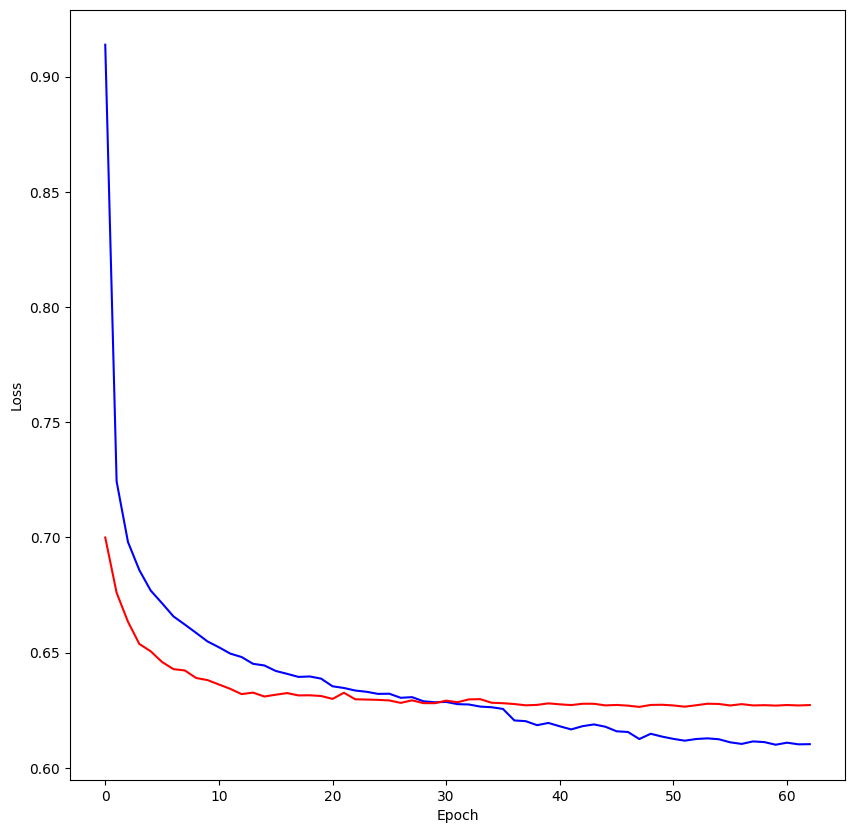

In [114]:
plt.figure(figsize = (10, 10))
plt.plot(history.history['loss'], label = 'Training Loss', color = 'blue')
plt.plot(history.history['val_loss'], label = 'Validation Loss', color = 'red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [115]:
mlp_pred_scaled = model.predict(X_test_scaled).ravel()

mlp_pred = scaler_y.inverse_transform(
    mlp_pred_scaled.reshape(-1, 1)).ravel()


mlp_rmse = np.sqrt(mean_squared_error(y_test, mlp_pred))
mlp_mae = mean_absolute_error(y_test, mlp_pred)
mlp_r2 = r2_score(y_test, mlp_pred)

print("MLP Results")
print("-----------")
print("RMSE:", mlp_rmse)
print("MAE:", mlp_mae)
print("R2:", mlp_r2)

1614/1614 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
MLP Results
-----------
RMSE: 8.750598124088254
MAE: 6.038388729095459
R2: 0.3497757911682129


**The MLP achieved an R² score of 0.35, which indicates that the model explains approximately 35% of the variance in the target variable. This is an improvement over the Gradient Boosting model, which achieved an R² of 0.30, but the improvement is relatively small. Therefore, although the MLP performs slightly better, the overall predictive power remains limited. This suggests that either the current features do not fully explain the target variable, the data contains substantial noise, or further feature engineering and model tuning are required.**